# package_DBR

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors
import math
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error, explained_variance_score


%config InlineBackend.figure_formats ="svg"
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode
from package_LAB import *


# Load data

In [2]:
nameFile = 'Cleaned_data_Open_loop_experiment_on_MV_2026-03-03-13h37.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)

if 'MV' in nameFile:
    ExpVariable = 'MV'
    tm = data['tm'].values
    MVm = data['MVm'].values
    PVm = data['PVm'].values    
else:    
    ExpVariable = 'DV'
    tm = data['tm'].values
    DVm = data['DVm'].values 
    PVm = data['PVm'].values
     
print(ExpVariable)    

MV


# Parameters optimal FOPDT & SOPDT models

In [3]:
Kp_FOPDTOPT =  0.3758531171265384
T_FOPDTOPT =  177.91106079753803
theta_FOPDTOPT = 35.49834262680672


Kp_SOPDTOPT = 0.37468470154135686
T1_SOPDTOPT = 171.14598529736972
T2_SOPDTOPT = 26.744640842976725
theta_SOPDTOPT = 12.008443834451233 

Ts = 1


Kp_graphical = 0.375
Tu_graphical = 30
Tg_graphical = 256
t1_graphical = 100
t2_graphical = 130
a_graphical = 0.115




# BROIDA Simple and complicated

In [4]:
def Broida_complicated(t1, t2):

    T = 5.5*(t2 - t1)
    theta = 2.8*t1 - 1.8*t2

    return (T, theta)


def Broida_simple(Tg, Tu):

    T = Tg
    theta = Tu
    return (T, theta)

T_BROIDA_simple , theta_BROIDA_simple = Broida_simple(Tg_graphical, Tu_graphical)

T_BROIDA_complicated , theta_BROIDA_complicated = Broida_complicated(t1_graphical, t2_graphical)

print(T_BROIDA_simple, theta_BROIDA_simple)
(T_BROIDA_complicated, theta_BROIDA_complicated)




256 30


(165.0, 46.0)

# Van der grinten

In [5]:

def Van_der_Grinten(a, Tu, Tg):
    e = math.exp(1)

    T1 = Tg*((3*a*e - 1)/(1 + a*e))
    T2 = Tg*((1 - a*e)/(1 + a*e))
    theta = Tu - ((T1*T2)/(T1 + 3*T2))

    return (T1, T2, theta)



T1_VDG , T2_VDG, theta_VDG = Van_der_Grinten(a_graphical, Tu_graphical, Tg_graphical)

(T1_VDG , T2_VDG, theta_VDG)

(-12.129605115678778, 134.06480255783939, 34.16893066043021)

# Strejc method

In [6]:

def Strejc(Tu, Tg):

    ratio = Tu/Tg

    match (ratio) :
        case n if 0 < n <= 0.1 :
            a_n = 0
            order = 1
            b_n = 1

        case n if 0.1 < n <= 0.22 :
            a_n = 0.1
            order =2
            b_n = 2.72

        case n if 0.22 < n <= 0.32 :
            a_n = 0.22
            order =3
            b_n = 3.69
        case _ :
            raise ValueError("error Tu/Tg ratio is too high")
    
    T = Tg / b_n
    Tuth = a_n * Tg
    theta = Tu -Tuth

    return (T,theta, order)




T_strejc , theta_strecj, order_strejc= Strejc(Tu_graphical, Tg_graphical)


(T_strejc, theta_strecj, order_strejc)

(94.11764705882352, 4.399999999999999, 2)

# Compare step responses MV (experiment compared with optimal FOPDT & SOPDT)

(0.0, 968.0)

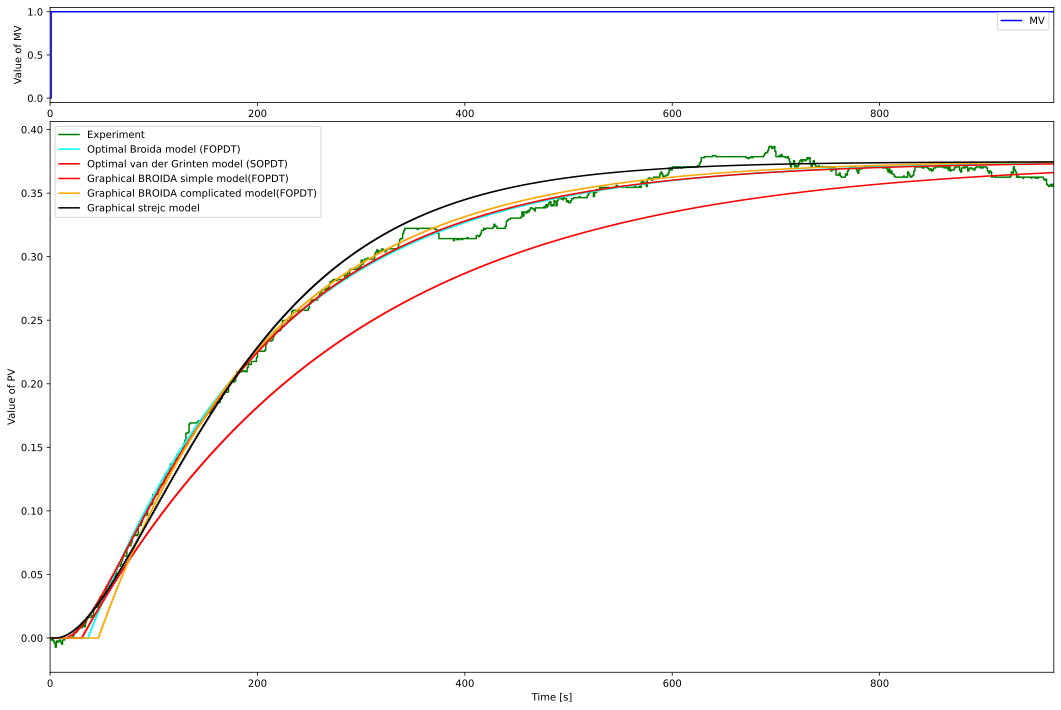

In [7]:
PV_SOPDTOPT = SOPDT(MVm,Kp_SOPDTOPT,T1_SOPDTOPT,T2_SOPDTOPT,theta_SOPDTOPT,Ts)
PV_FOPDTOPT = FOPDT(MVm,Kp_FOPDTOPT,T_FOPDTOPT,theta_FOPDTOPT,Ts)
PV_BROIDA_simple = FOPDT(MVm,Kp_FOPDTOPT,T_BROIDA_simple,theta_BROIDA_simple,Ts)
PV_BROIDA_complicated = FOPDT(MVm,Kp_FOPDTOPT,T_BROIDA_complicated, theta_BROIDA_complicated, Ts)

if order_strejc == 1 :

    PV_strejc= FOPDT(MVm,Kp_FOPDTOPT,T_strejc,theta_strecj,Ts)

if order_strejc == 2 :
    PV_strejc= SOPDT(MVm,Kp_SOPDTOPT,T_strejc,T_strejc,theta_strecj,Ts)

PV_VDG= SOPDT(MVm,Kp_SOPDTOPT,T1_VDG,T2_VDG,theta_VDG,Ts)


plt.figure(figsize = (18,12))

plt.subplot(6,1,1)
plt.step(tm,MVm,'b-',label='MV',where='post')
plt.ylabel('Value of MV')
plt.legend(loc='best')
plt.xlim([0, np.max(tm)])   

plt.subplot(6,1,(2,6))
plt.step(tm,PVm,'g-',label='Experiment',where='post')
plt.step(tm,PV_FOPDTOPT,'cyan',label='Optimal Broida model (FOPDT)',where='post')
plt.step(tm,PV_SOPDTOPT,'red',label='Optimal van der Grinten model (SOPDT)',where='post')
plt.step(tm,PV_BROIDA_simple,'red',label='Graphical BROIDA simple model(FOPDT)',where='post')
plt.step(tm,PV_BROIDA_complicated,'orange',label='Graphical BROIDA complicated model(FOPDT)',where='post')
plt.step(tm,PV_strejc,'black',label='Graphical strejc model',where='post')
# T1 is negative so theorically one of our poles is on the right side wich means that the system is unstable
# plt.step(tm,PV_VDG,'blue',label='Graphical BROIDA complicated model(FOPDT)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')  
plt.xlim([0, np.max(tm)])


# Metrique de performances



In [8]:

def Error_quant(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred),
        "MedianAE": median_absolute_error(y_true, y_pred)
    }




print(Error_quant(PVm,PVm))
print(Error_quant(PVm,PV_FOPDTOPT))
print(Error_quant(PVm,PV_SOPDTOPT))
print(Error_quant(PVm,PV_BROIDA_simple))
print(Error_quant(PVm,PV_BROIDA_complicated))
print(Error_quant(PVm,PV_strejc))



{'R2': 1.0, 'MAE': 0.0, 'RMSE': 0.0, 'MedianAE': 0.0}
{'R2': 0.9952003705046251, 'MAE': 0.0057383740961143076, 'RMSE': 5.492336641410279e-05, 'MedianAE': 0.004264316282503178}
{'R2': 0.9954314058411846, 'MAE': 0.005409838496993413, 'RMSE': 5.227957100099977e-05, 'MedianAE': 0.0036193115228950468}
{'R2': 0.9188432918435312, 'MAE': 0.026324965412391804, 'RMSE': 0.0009286966052974254, 'MedianAE': 0.028789861764100755}
{'R2': 0.9934542278189357, 'MAE': 0.006807349047436333, 'RMSE': 7.490491595450693e-05, 'MedianAE': 0.0055392209587018515}
{'R2': 0.9866120700114852, 'MAE': 0.009908645783319573, 'RMSE': 0.00015320144711047226, 'MedianAE': 0.008221740334913366}


# Compare Bode diagrams (optimal FOPDT & SOPDT)

Text(0, 0.5, 'Phase [°]')

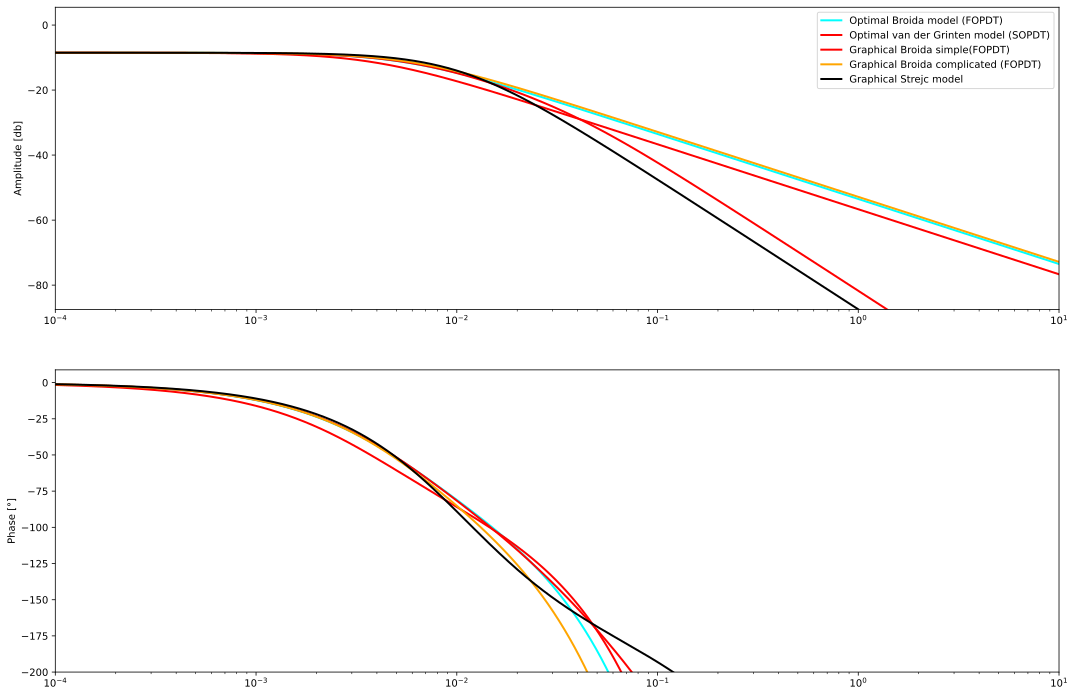

In [9]:
# Frequency response
P_FOPDTOPT = Process({})
P_FOPDTOPT.parameters['Kp'] = Kp_FOPDTOPT
P_FOPDTOPT.parameters['Tlag1'] = T_FOPDTOPT
P_FOPDTOPT.parameters['theta'] = theta_FOPDTOPT

# Frequency response
P_SOPDTOPT = Process({})
P_SOPDTOPT.parameters['Kp'] = Kp_SOPDTOPT
P_SOPDTOPT.parameters['Tlag1'] = T1_SOPDTOPT
P_SOPDTOPT.parameters['Tlag2'] = T2_SOPDTOPT
P_SOPDTOPT.parameters['theta'] = theta_SOPDTOPT

# Frequency response
P_BROIDA_simple = Process({})
P_BROIDA_simple.parameters['Kp'] = Kp_FOPDTOPT
P_BROIDA_simple.parameters['Tlag1'] = T_BROIDA_simple
P_BROIDA_simple.parameters['theta'] = theta_BROIDA_simple


# Frequency response
P_BROIDA_complicated = Process({})
P_BROIDA_complicated.parameters['Kp'] = Kp_FOPDTOPT
P_BROIDA_complicated.parameters['Tlag1'] = T_BROIDA_complicated
P_BROIDA_complicated.parameters['theta'] = theta_BROIDA_complicated


# Frequency response
if order_strejc == 1 :
    P_strejc = Process({})
    P_strejc.parameters['Kp'] = Kp_FOPDTOPT
    P_strejc.parameters['Tlag1'] = T_strejc
    P_strejc.parameters['theta'] = theta_strecj

if order_strejc == 2 :
    P_strejc = Process({})
    P_strejc.parameters['Kp'] = Kp_FOPDTOPT
    P_strejc.parameters['Tlag1'] = T_strejc
    P_strejc.parameters['Tlag2'] = T_strejc
    P_strejc.parameters['theta'] = theta_strecj




omega = np.logspace(-4, 1, 10000)
Ps_FOPDTOPT = Bode(P_FOPDTOPT,omega,False) # Optimal Broida
Ps_SOPDTOPT = Bode(P_SOPDTOPT,omega,False) # Optimal van der Grinten
Ps_BROIDA_simple = Bode(P_BROIDA_simple,omega,False) # graphical Broida simple
Ps_BROIDA_complicated = Bode(P_BROIDA_complicated,omega,False) # graphical Broida complicated
Ps_strejc= Bode(P_strejc,omega,False) # graphical Broida complicated
plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
gain_min = np.min(20*np.log10(np.abs(Ps_FOPDTOPT)/5))
gain_max = np.max(20*np.log10(np.abs(Ps_FOPDTOPT)*5))
plt.semilogx(omega,20*np.log10(np.abs(Ps_FOPDTOPT)),'cyan',linewidth=2,label='Optimal Broida model (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_SOPDTOPT)),'red',linewidth=2,label='Optimal van der Grinten model (SOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_BROIDA_simple)),'red',linewidth=2,label='Graphical Broida simple(FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_BROIDA_complicated )),'orange',linewidth=2,label='Graphical Broida complicated (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_strejc )),'black',linewidth=2,label='Graphical Strejc model')
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([gain_min, gain_max])
plt.ylabel('Amplitude [db]')
plt.legend(loc='best')

plt.subplot(2,1,2)
ph_min = np.min((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) - 10
ph_max = np.max((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) + 10
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT)),'cyan',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_SOPDTOPT)),'red',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_BROIDA_simple)),'red',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_BROIDA_complicated)),'orange',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_strejc)),'black',linewidth=2)
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([np.max([ph_min, -200]), ph_max])
plt.ylabel('Phase [°]')

# Error Margin 

Kc =  5.412427033051363
Ti =  197.89062614034646
Td =  23.13014010703718


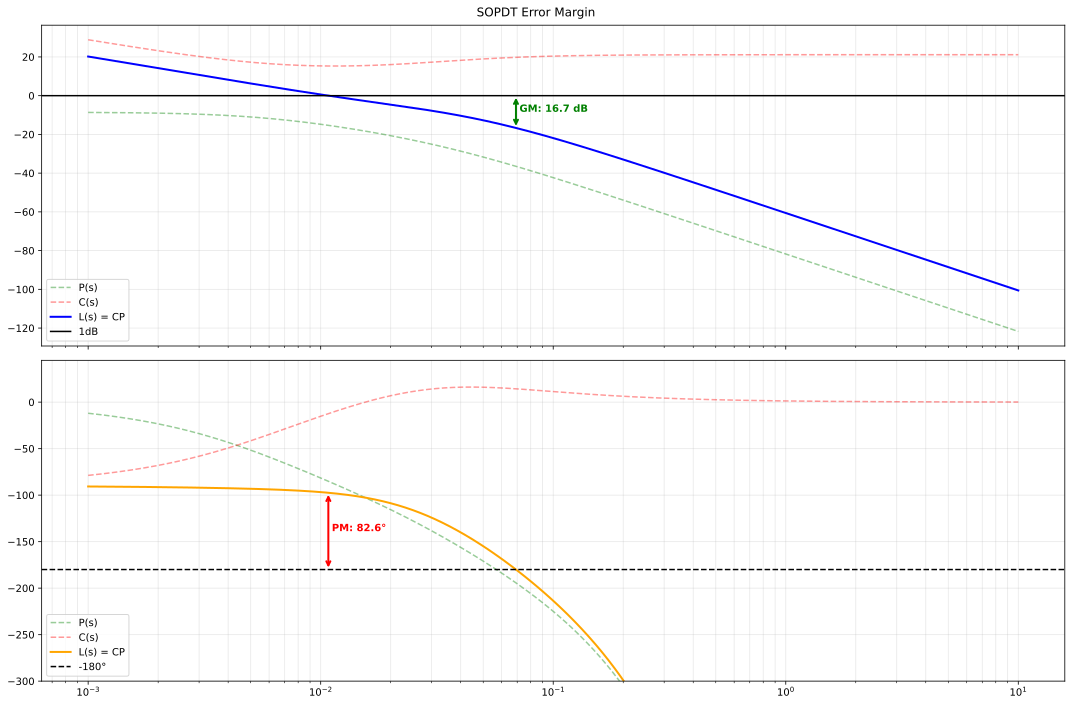

(np.float64(16.67383320668109), np.float64(82.56262995841847))
Kc =  5.0951357376005095
Ti =  188.23529411764704
Td =  47.05882352941176


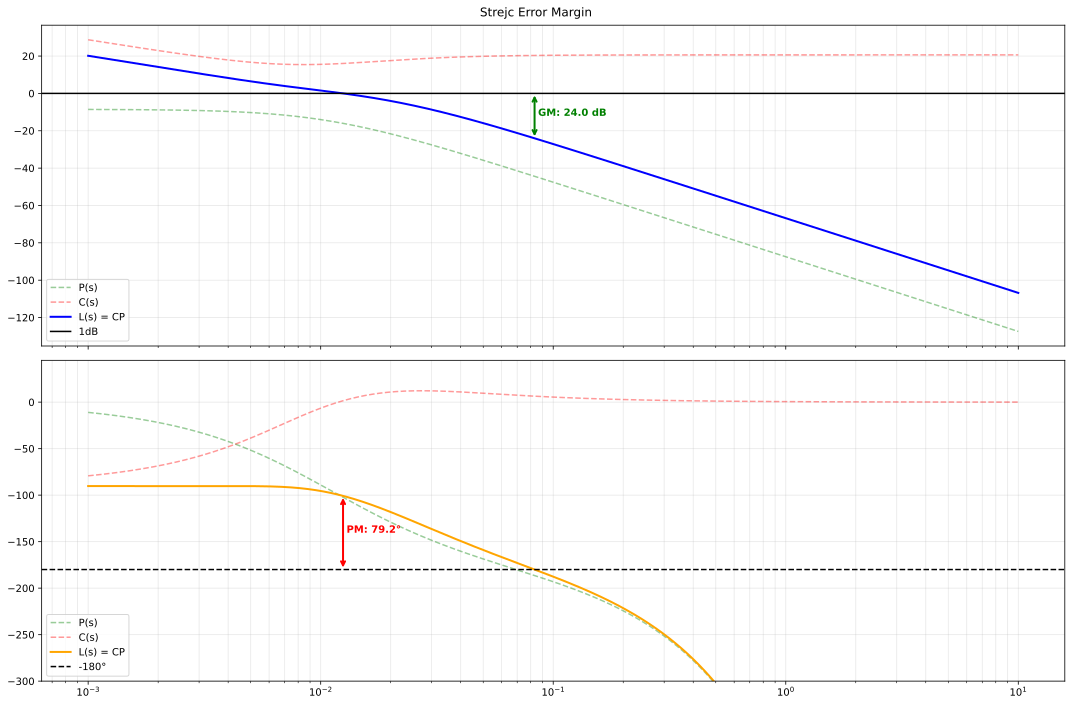

(np.float64(24.039046874275787), np.float64(79.21834410997901))
Kc =  3.8120910496903893
Ti =  177.91106079753803
Td =  0.0


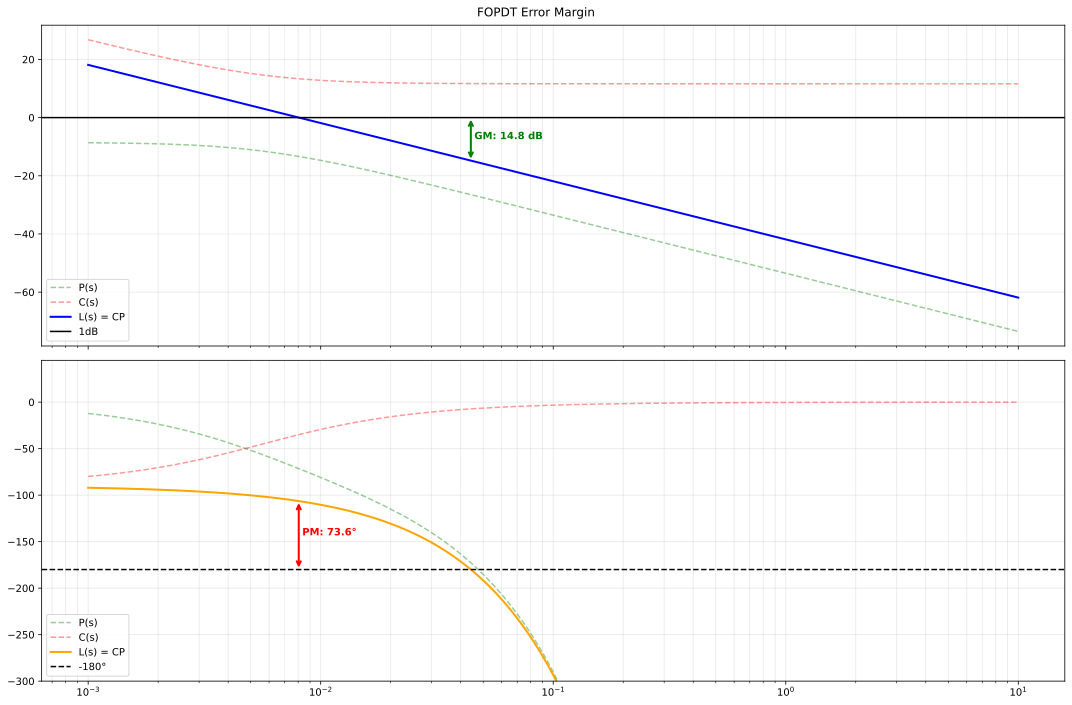

(np.float64(14.795722085054239), np.float64(73.63103280516393))
Kc =  4.320675105485232
Ti =  256
Td =  0.0


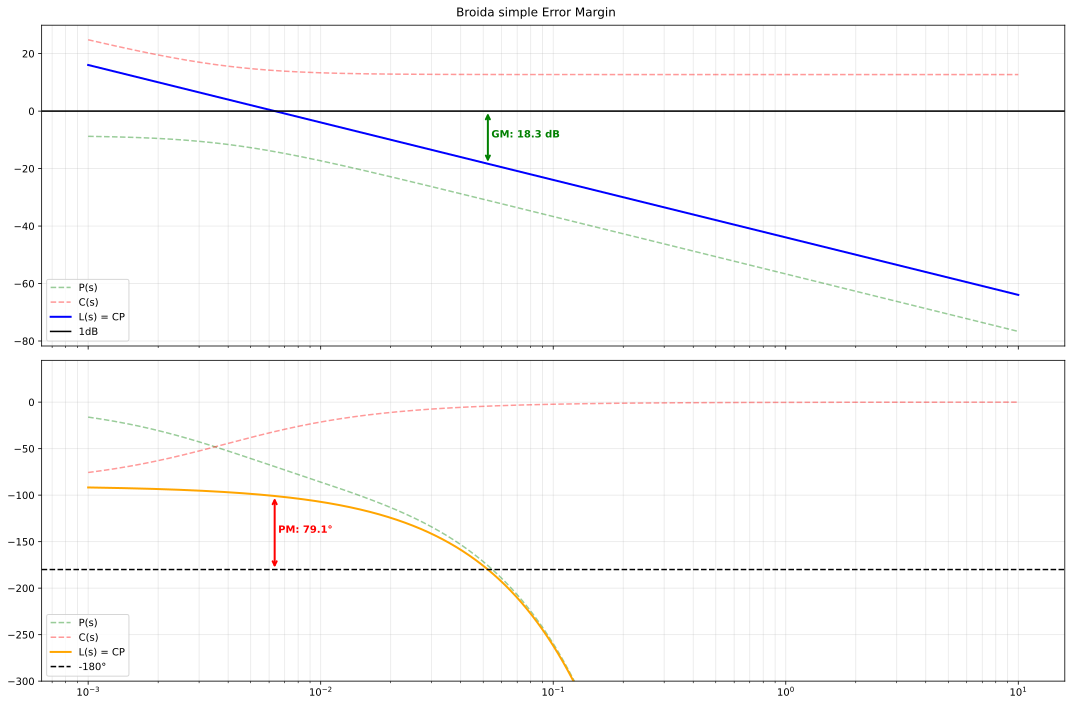

(np.float64(18.33284190933138), np.float64(79.10256982044373))
Kc =  3.424124513618677
Ti =  165.0
Td =  0.0


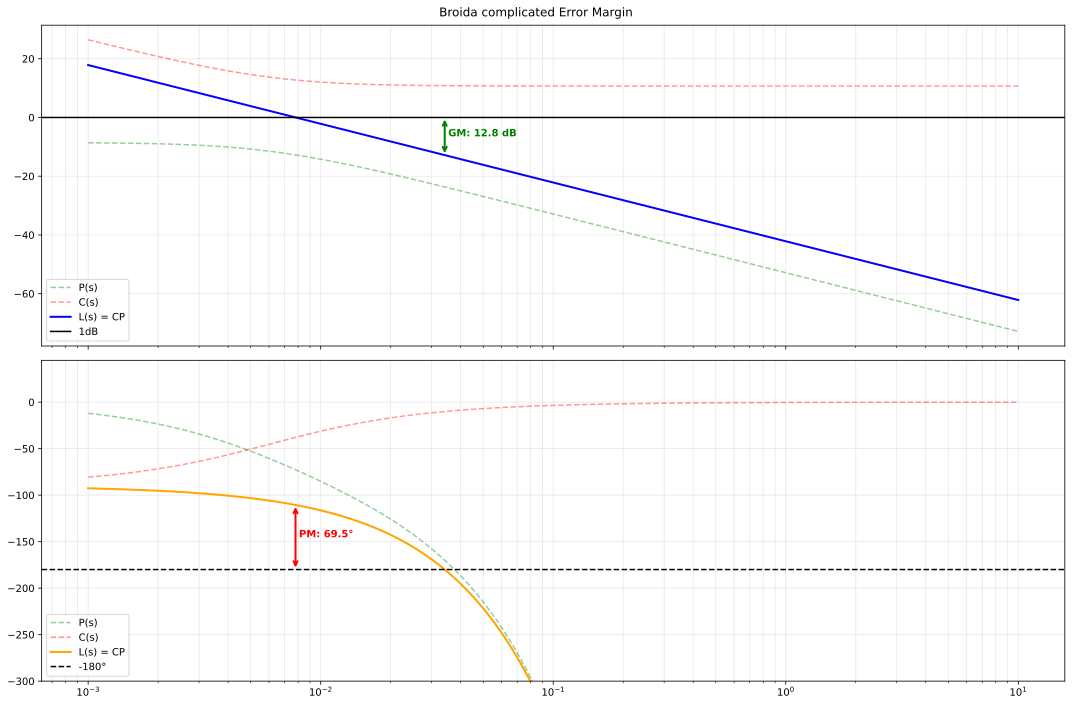

(np.float64(12.825391486465477), np.float64(69.46145693310453))


In [10]:


#SOPDT-----------------------------------------------------------------------------------------------------------------------
gamma = 0.5
Kc,Ti,Td = IMC_Tuning(Kp_SOPDTOPT, gamma,theta_SOPDTOPT , T1_SOPDTOPT, T2_SOPDTOPT, 2)


print("Kc = ", Kc)
print("Ti = ", Ti)
print("Td = ", Td)

C = PID({})

C.parameters['Kc'] = Kc
C.parameters['Td'] = Td
C.parameters['Ti'] = Ti
C.parameters['alpha'] = 0.9

omega = np.logspace(-3, 1, 10000)
print(Margin_error(P_SOPDTOPT, C , omega, "SOPDT Error Margin"))


#Strejc-----------------------------------------------------------------------------------------------------------------------

gamma = 0.5
Kc,Ti,Td = IMC_Tuning(Kp_graphical, gamma,theta_strecj , T_strejc, T_strejc, 2)


print("Kc = ", Kc)
print("Ti = ", Ti)
print("Td = ", Td)

C = PID({})

C.parameters['Kc'] = Kc
C.parameters['Td'] = Td
C.parameters['Ti'] = Ti
C.parameters['alpha'] = 0.9

omega = np.logspace(-3, 1, 10000)
print(Margin_error(P_strejc, C , omega, "Strejc Error Margin"))



#FOPDT-----------------------------------------------------------------------------------------------------------------------

gamma = 0.5
Kc,Ti,Td = IMC_Tuning(Kp_graphical, gamma,theta_FOPDTOPT , T_FOPDTOPT, 0, 2)


print("Kc = ", Kc)
print("Ti = ", Ti)
print("Td = ", Td)

C = PID({})

C.parameters['Kc'] = Kc
C.parameters['Td'] = Td
C.parameters['Ti'] = Ti
C.parameters['alpha'] = 0.9

omega = np.logspace(-3, 1, 10000)
print(Margin_error(P_FOPDTOPT, C , omega, "FOPDT Error Margin"))



#BROIDA SIMPLE-----------------------------------------------------------------------------------------------------------------------

gamma = 0.5
Kc,Ti,Td = IMC_Tuning(Kp_graphical, gamma,theta_BROIDA_simple , T_BROIDA_simple, 0, 2)


print("Kc = ", Kc)
print("Ti = ", Ti)
print("Td = ", Td)

C = PID({})

C.parameters['Kc'] = Kc
C.parameters['Td'] = Td
C.parameters['Ti'] = Ti
C.parameters['alpha'] = 0.9

omega = np.logspace(-3, 1, 10000)
print(Margin_error(P_BROIDA_simple, C , omega, "Broida simple Error Margin"))


#BROIDA COMPLICATED-----------------------------------------------------------------------------------------------------------------------

gamma = 0.5
Kc,Ti,Td = IMC_Tuning(Kp_graphical, gamma,theta_BROIDA_complicated , T_BROIDA_complicated, 0, 2)


print("Kc = ", Kc)
print("Ti = ", Ti)
print("Td = ", Td)

C = PID({})

C.parameters['Kc'] = Kc
C.parameters['Td'] = Td
C.parameters['Ti'] = Ti
C.parameters['alpha'] = 0.9

omega = np.logspace(-3, 1, 10000)
print(Margin_error(P_BROIDA_complicated, C , omega, "Broida complicated Error Margin"))



# DV  values OLP

## Reloading data

In [11]:
nameFile = 'Cleaned_data_Open_loop_experiment_on_DV_2026-03-04-18h52.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)

if 'MV' in nameFile:
    ExpVariable = 'MV'
    tm = data['tm'].values
    MVm = data['MVm'].values
    PVm = data['PVm'].values    
else:    
    ExpVariable = 'DV'
    tm = data['tm'].values
    DVm = data['DVm'].values 
    PVm = data['PVm'].values
     
print(ExpVariable)    

DV


# Parameter optimal DV (FOPDT & SOPDT)

In [12]:
Kp_FOPDTOPT_DV =  0.3956172303278946
T_FOPDTOPT_DV =  174.43578111991812
theta_FOPDTOPT_DV = 38.3308784234789


Kp_SOPDTOPT_DV = 0.393368177568377
T1_SOPDTOPT_DV = 161.75194144935833
T2_SOPDTOPT_DV = 36.28794803765712
theta_SOPDTOPT_DV = 9.570305019620053



Ts = 1

# Compare step responses DV (optimal FOPDT & SOPDT)

{'R2': 0.9964042217771838, 'MAE': 0.005083654752846328, 'RMSE': 4.549443014834081e-05, 'MedianAE': 0.003460830110756874}
{'R2': 0.997444878118013, 'MAE': 0.00433083657902438, 'RMSE': 3.232785972253707e-05, 'MedianAE': 0.0033008426201322494}


(0.0, 968.0)

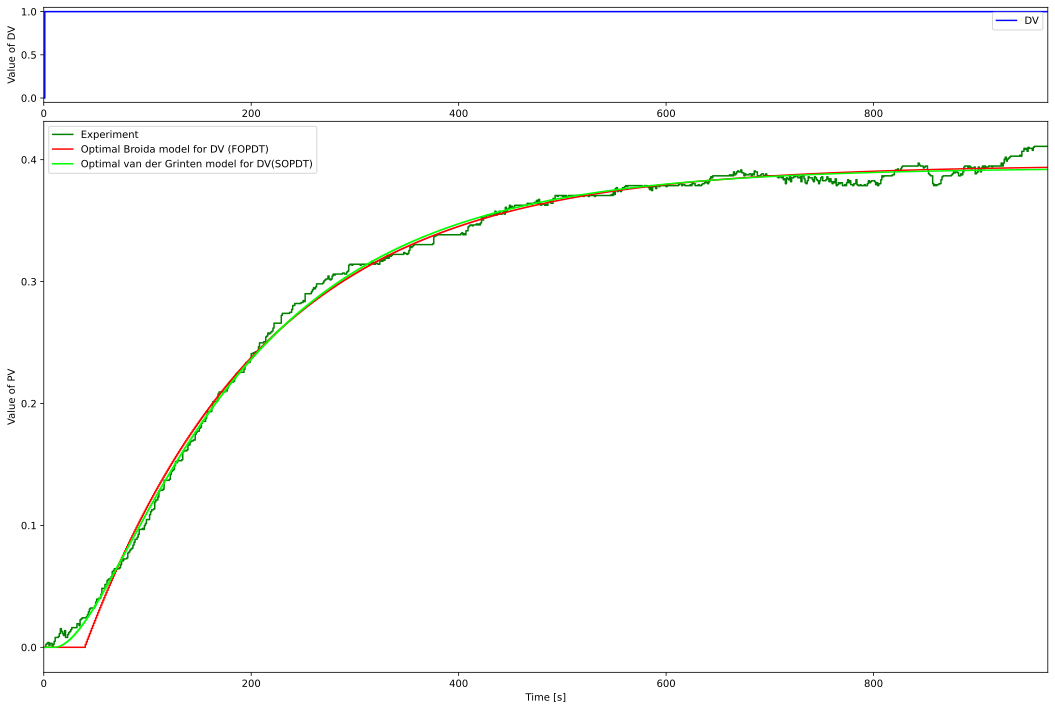

In [13]:
PV_SOPDTOPT_DV = SOPDT(DVm ,Kp_SOPDTOPT_DV,T1_SOPDTOPT_DV,T2_SOPDTOPT_DV,theta_SOPDTOPT_DV,Ts)
PV_FOPDTOPT_DV = FOPDT(DVm ,Kp_FOPDTOPT_DV,T_FOPDTOPT_DV,theta_FOPDTOPT_DV,Ts)



print(Error_quant(PVm,PV_FOPDTOPT_DV))
print(Error_quant(PVm,PV_SOPDTOPT_DV))


plt.figure(figsize = (18,12))

plt.subplot(6,1,1)
plt.step(tm,DVm,'b-',label='DV',where='post')
plt.ylabel('Value of DV')
plt.legend(loc='best')
plt.xlim([0, np.max(tm)])   

plt.subplot(6,1,(2,6))
plt.step(tm,PVm,'g-',label='Experiment',where='post')
plt.step(tm,PV_FOPDTOPT_DV,'red',label='Optimal Broida model for DV (FOPDT)',where='post')
plt.step(tm,PV_SOPDTOPT_DV,'lime',label='Optimal van der Grinten model for DV(SOPDT)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')  
plt.xlim([0, np.max(tm)])


Text(0.5, 0, 'Angular frequency [rad/s]')

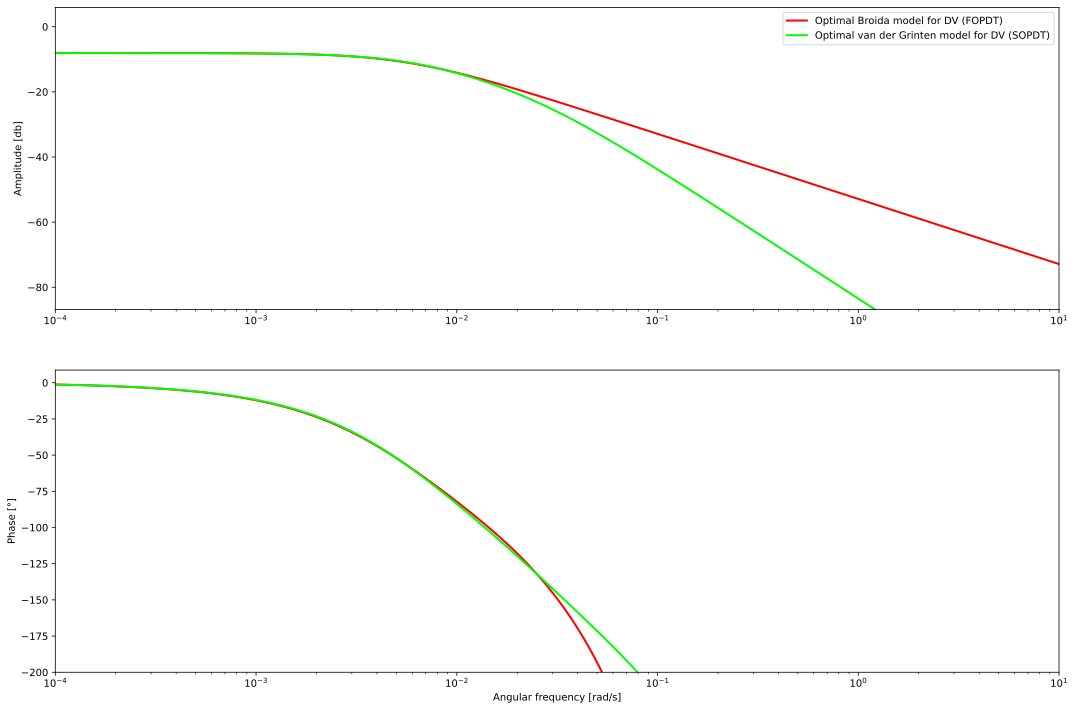

In [14]:
# Frequency response
P_FOPDTOPT_DV = Process({})
P_FOPDTOPT_DV.parameters['Kp'] = Kp_FOPDTOPT_DV
P_FOPDTOPT_DV.parameters['Tlag1'] = T_FOPDTOPT_DV
P_FOPDTOPT_DV.parameters['theta'] = theta_FOPDTOPT_DV

# Frequency response
P_SOPDTOPT_DV = Process({})
P_SOPDTOPT_DV.parameters['Kp'] = Kp_SOPDTOPT_DV
P_SOPDTOPT_DV.parameters['Tlag1'] = T1_SOPDTOPT_DV
P_SOPDTOPT_DV.parameters['Tlag2'] = T2_SOPDTOPT_DV
P_SOPDTOPT_DV.parameters['theta'] = theta_SOPDTOPT_DV


omega = np.logspace(-4, 1, 10000)
Ps_FOPDTOPT_DV = Bode(P_FOPDTOPT_DV,omega,False) # Optimal Broida
Ps_SOPDTOPT_DV = Bode(P_SOPDTOPT_DV,omega,False) # Optimal van der Grinten

plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
gain_min = np.min(20*np.log10(np.abs(Ps_FOPDTOPT_DV)/5))
gain_max = np.max(20*np.log10(np.abs(Ps_FOPDTOPT_DV)*5))
plt.semilogx(omega,20*np.log10(np.abs(Ps_FOPDTOPT_DV)),'red',linewidth=2,label='Optimal Broida model for DV (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_SOPDTOPT_DV)),'lime',linewidth=2,label='Optimal van der Grinten model for DV (SOPDT)')
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([gain_min, gain_max])
plt.ylabel('Amplitude [db]')
plt.legend(loc='best')

plt.subplot(2,1,2)
ph_min = np.min((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT_DV))) - 10
ph_max = np.max((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT_DV))) + 10
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT_DV)),'red',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_SOPDTOPT_DV)),'lime',linewidth=2)
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([np.max([ph_min, -200]), ph_max])
plt.ylabel('Phase [°]')
plt.xlabel("Angular frequency [rad/s]")